# Implementing a simple conditional Workflow using the quadratic equations concept

In [14]:
from typing import TypedDict, Literal
from langgraph.graph import START, END, StateGraph
from IPython.display import Image

In [3]:
# Define the input type for the workflow
class WorkflowInput(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str


In [ ]:
# Functions:
def create_equation(state: WorkflowInput) -> WorkflowInput:
    state['equation'] = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return state

def calculate_discriminant(state: WorkflowInput) -> WorkflowInput:
    state['discriminant'] = state['b'] ** 2 - 4 * state['a'] * state['c']
    return state

def real_roots(state: WorkflowInput) -> WorkflowInput:
    root1 = (-state['b'] + state['discriminant'] ** 0.5) / (2 * state['a'])
    root2 = (-state['b'] - state['discriminant'] ** 0.5) / (2 * state['a'])
    state['result'] = f"Real roots: {root1} and {root2}"
    return state

def repeated_roots(state: WorkflowInput) -> WorkflowInput:
    root = -state['b'] / (2 * state['a'])
    state['result'] = f"Repeated root: {root}"
    return state

def no_real_roots(state: WorkflowInput) -> WorkflowInput:
    state['result'] = "No real roots"
    return state

# Conditional function:
def determine_root_type(state: WorkflowInput) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [9]:
# Initalizing the graph : 
graph = StateGraph(WorkflowInput)

# Nodes:
graph.add_node("create_equation", create_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_real_roots", no_real_roots)

graph.add_edge(START, "create_equation")
graph.add_edge("create_equation", "calculate_discriminant")

# Condtional Edge:
graph.add_conditional_edges("calculate_discriminant", determine_root_type)

graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()


In [12]:
# Executing the graph:
initial_state = {
    'a': 1,
    'b': -8,
    'c': 2,
    'equation': '',
    'discriminant': 0.0,
    'result': ''
}

final = workflow.invoke(initial_state)
print(final)

{'a': 1, 'b': -8, 'c': 2, 'equation': '1x^2 + -8x + 2 = 0', 'discriminant': 56, 'result': 'Real roots: 7.741657386773941 and 0.25834261322605867'}


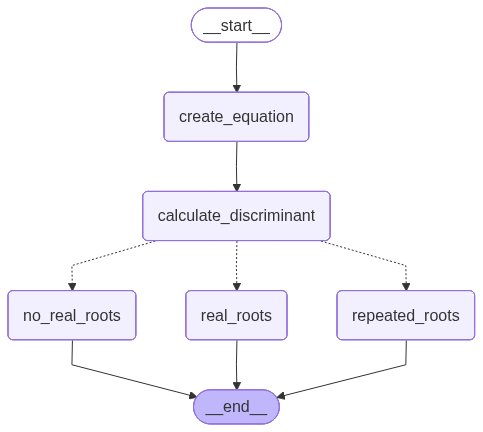

In [15]:
Image(workflow.get_graph().draw_mermaid_png())